In [1]:
import os
import warnings
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
from tqdm import tqdm

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [3]:
speech_path = "../datasets/speech/Audio_Speech_Actors_01-24"

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fear",
    "07": "disgust",
    "08": "surprised"
}

Read

In [4]:
audio_paths = []
labels = []

for actor in sorted(os.listdir(speech_path)):

    actor_path = os.path.join(speech_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in sorted(os.listdir(actor_path)):

        if file.endswith(".wav"):

            emotion = emotion_map[file.split("-")[2]]

            audio_paths.append(
                os.path.join(actor_path, file)
            )

            labels.append(emotion)

speech_df = pd.DataFrame({
    "Path": audio_paths,
    "Emotion": labels
})

speech_df.head()

,Path,Emotion
0,../datasets/speech/Audio_Speech_Actors_01-24\A...,neutral
1,../datasets/speech/Audio_Speech_Actors_01-24\A...,neutral
2,../datasets/speech/Audio_Speech_Actors_01-24\A...,neutral
3,../datasets/speech/Audio_Speech_Actors_01-24\A...,neutral
4,../datasets/speech/Audio_Speech_Actors_01-24\A...,calm


Feature exutraction

Instead of using only MFCCs, we'll extract multiple audio features.

This is the same idea used in many strong RAVDESS projects.

For each audio file we'll compute:

40 MFCC means

Chroma means

Mel Spectrogram means

Spectral Contrast means

Zero Crossing Rate

RMS Energy

This gives us a compact but informative feature vector for every sample.

In [5]:
def extract_features(file_path):
    signal, sr = librosa.load(file_path, sr=22050)

    # MFCC
    mfcc = np.mean(
        librosa.feature.mfcc(
            y=signal,
            sr=sr,
            n_mfcc=40
        ).T,
        axis=0
    )

    # Chroma
    chroma = np.mean(
        librosa.feature.chroma_stft(
            y=signal,
            sr=sr
        ).T,
        axis=0
    )

    # Mel Spectrogram
    mel = np.mean(
        librosa.feature.melspectrogram(
            y=signal,
            sr=sr
        ).T,
        axis=0
    )

    # Spectral Contrast
    contrast = np.mean(
        librosa.feature.spectral_contrast(
            y=signal,
            sr=sr
        ).T,
        axis=0
    )

    # Zero Crossing Rate
    zcr = np.mean(
        librosa.feature.zero_crossing_rate(signal)
    )

    # RMS Energy
    rms = np.mean(
        librosa.feature.rms(y=signal)
    )

    feature_vector = np.hstack([
        mfcc,
        chroma,
        mel,
        contrast,
        zcr,
        rms
    ])

    return feature_vector

Extract features for all audio files

In [6]:
X = []
y = []

for _, row in tqdm(speech_df.iterrows(), total=len(speech_df)):

    feature_vector = extract_features(row["Path"])

    X.append(feature_vector)

    y.append(row["Emotion"])

X = np.array(X)
y = np.array(y)

print("Feature Matrix Shape :", X.shape)
print("Labels Shape :", y.shape)

100%|██████████| 1440/1440 [00:55<00:00, 26.13it/s]

Feature Matrix Shape : (1440, 189)
Labels Shape : (1440,)


encode labels

In [7]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['angry' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprised']


Train-test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

feature scaling

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [10]:
os.makedirs("../models/encoders", exist_ok=True)

joblib.dump(
    label_encoder,
    "../models/encoders/speech_label_encoder.pkl"
)

joblib.dump(
    scaler,
    "../models/encoders/speech_scaler.pkl"
)

['../models/encoders/speech_scaler.pkl']

# Train the models 

lets strat with Logistic regression

In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_acc)

Logistic Regression Accuracy : 0.5173611111111112


Train the Random forest

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_acc)

Random Forest Accuracy : 0.5277777777777778


Train SVM

In [13]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy :", svm_acc)

SVM Accuracy : 0.625


In [14]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],

    "Accuracy": [
        lr_acc,
        rf_acc,
        svm_acc
    ]

})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,SVM,0.625000
1,Random Forest,0.527778
0,Logistic Regression,0.517361


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C": [1, 5, 10, 20, 50],
    "gamma": ["scale", 0.01, 0.001, 0.0001],
    "kernel": ["rbf"]
}

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Accuracy: 0.663150762281197


In [16]:
best_svm = grid.best_estimator_

y_pred = best_svm.predict(X_test)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.6805555555555556


In [17]:
joblib.dump(best_svm, "../models/saved_models/speech_emotion_svm.pkl")

['../models/saved_models/speech_emotion_svm.pkl']

In [18]:
model = best_svm
y_pred = model.predict(X_test)

In [27]:
model = best_svm

y_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy : {test_accuracy:.4f}")

Test Accuracy : 0.6806


In [20]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

       angry       0.68      0.84      0.75        38
        calm       0.79      0.89      0.84        38
     disgust       0.66      0.76      0.71        38
        fear       0.60      0.64      0.62        39
       happy       0.71      0.44      0.54        39
     neutral       0.45      0.47      0.46        19
         sad       0.76      0.58      0.66        38
   surprised       0.72      0.72      0.72        39

    accuracy                           0.68       288
   macro avg       0.67      0.67      0.66       288
weighted avg       0.68      0.68      0.67       288



In [21]:
os.makedirs("../reports", exist_ok=True)

with open("../reports/speech_classification_report.txt", "w") as f:
    f.write(report)

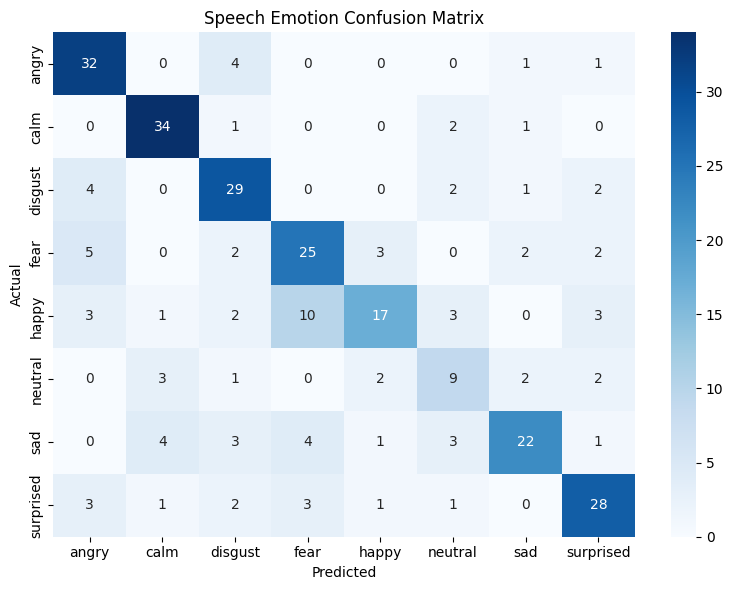

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Speech Emotion Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/figures/speech_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

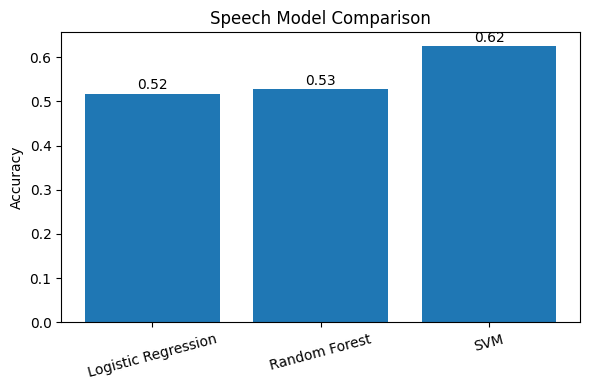

In [24]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title("Speech Model Comparison")

plt.xticks(rotation=15)

for i, value in enumerate(comparison["Accuracy"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../reports/figures/speech_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM (Tuned)"
    ],
    "Accuracy": [
        lr_acc,
        rf_acc,
        test_accuracy
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
2,SVM (Tuned),0.680556
1,Random Forest,0.527778
0,Logistic Regression,0.517361


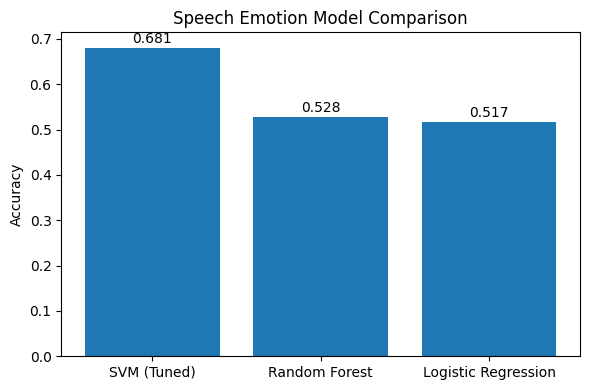

In [26]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Speech Emotion Model Comparison")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../reports/figures/speech_model_comparison.png",
    dpi=300
)

plt.show()

In [28]:
joblib.dump(
    best_svm,
    "../models/saved_models/speech_emotion_svm.pkl"
)

['../models/saved_models/speech_emotion_svm.pkl']

In [29]:
with open("../reports/speech_test_accuracy.txt", "w") as f:
    f.write(f"Speech Emotion Recognition Test Accuracy: {test_accuracy:.4f}")